In [40]:
# Importing necessary libraries
import numpy as np
import pandas as pd
from typing import (
    Literal,
)

import torch
import torch.nn.functional as F # Padding
from torch.utils.data import Dataset, DataLoader
from torch.nn import Module, Embedding, RNN, Linear

# Device setup
device: Literal['cpu', 'cuda'] = 'cuda' if torch.cuda.is_available() else 'cpu'
if device != "cpu":
    print(torch.cuda.get_device_name())

NVIDIA GeForce MX350


In [41]:
# Loading the dataset
df: pd.DataFrame = pd.read_csv(filepath_or_buffer="data/questions and answers.csv")
df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [42]:
# Preprocessing
class Preprocess:
    def __init__(self):
        self.vocab: dict[str, int] = {'<UNK>': -1, '<PAD>': 0}

    # Low - level preprocessing
    def preprocess(self: Preprocess, text: str) -> list[str]:
        text = text.lower()
        text = text.replace("?", "").replace("'", "")
        return text.split(sep=" ")

    # Padding
    def pad_sequences(
        self: Preprocess, 
        text_tensor: torch.Tensor, 
        max_len: int, 
        mode: str = 'post' # default
    ) -> torch.Tensor:
        pad_size: int = max_len - len(text_tensor)
        if pad_size <= 0:
            return text_tensor[:max_len]
        
        if mode == 'post':
            # Pad on the right (Post-padding)
            return F.pad(input=text_tensor, pad=[0, pad_size], mode='constant', value=0)
        else:
            # Pad on the left (Pre-padding)
            return F.pad(input=text_tensor, pad=[pad_size, 0], mode='constant', value=0)

    # Vocabulary building
    def build_vocab(self: Preprocess, row: pd.Series) -> None:
        merged_tokens: list[str] = self.preprocess(row['question']) + self.preprocess(row['answer'])

        for token in merged_tokens:
            if token not in self.vocab:
                self.vocab[token] = len(self.vocab)

    # Tokenizing functions
    def text_to_indices(self: Preprocess, text: str, vocab: dict) -> list[int]:
        indexed_text: list[np.int32] = []

        for token in self.preprocess(text):
            idx = vocab.get(token, vocab['<UNK>']) # Return the value for key if key is in the dictionary, else default.
            indexed_text.append(idx) 
        
        return indexed_text

In [43]:
# Dataset
class CustomDataset(Dataset):
    def __init__(self: CustomDataset, df: pd.DataFrame, mode: str) -> None:
        super().__init__()

        self.df = df
        self.mode = mode
        self.preprocess = Preprocess()
        
        # Find global max lengths across the dataframe
        self.max_q_len = self.df["question"].apply(self.preprocess.preprocess).str.len().max()
        self.max_a_len = self.df["answer"].apply(self.preprocess.preprocess).str.len().max()

        # Vocabulary building
        self.df.apply(self.preprocess.build_vocab, axis=1)
        self.vocab = self.preprocess.vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int) -> tuple[torch.tensor]:
        doc = self.df.iloc[index]
        
        # Tokenizing
        q_indices = self.preprocess.text_to_indices(doc["question"], self.vocab)
        a_indices = self.preprocess.text_to_indices(doc["answer"], self.vocab)
        
        # Padding (pre/post)
        question: torch.Tensor = self.preprocess.pad_sequences(torch.tensor(q_indices), self.max_q_len, mode=self.mode)
        
        # NOTE: There is no need to pad the answers (here) since the answers are just one word
        answer: torch.Tensor = self.preprocess.pad_sequences(torch.tensor(a_indices), self.max_a_len, mode='post')
        
        return question, answer

In [44]:
# Building Dataloaders
pre_padded_dataset = CustomDataset(df=df, mode="pre")
post_padded_dataset = CustomDataset(df=df, mode="post")

pre_padded_dataloader = DataLoader(dataset=pre_padded_dataset, batch_size=32, shuffle=True)
post_padded_dataloader = DataLoader(dataset=post_padded_dataset, batch_size=32, shuffle=True)

In [45]:
# Model Building
class SimpleRNN(Module):
    def __init__(self, vocab_size: int) -> None:
        super().__init__()
        self.embedding = Embedding(num_embeddings=vocab_size, embedding_dim=64)
        self.rnn = RNN(input_size=64, hidden_size=64, batch_first=True)
        self.linear = Linear(in_features=64, out_features=vocab_size)

    def forward(self, question) -> torch.Tensor:
        embedded = self.embedding(question)
        hidden, final = self.rnn(embedded)
        return self.linear(torch.squeeze(final, dim=0)) # num_layer dimension got squeezed 

In [46]:
post_model = SimpleRNN(len(post_padded_dataset.vocab)).to(device)
pre_model = SimpleRNN(len(pre_padded_dataset.vocab)).to(device)

criterion = torch.nn.CrossEntropyLoss()
lr = 0.001
epochs = 50

post_optimizer = torch.optim.Adam(post_model.parameters(), lr=lr)
pre_optimizer = torch.optim.Adam(pre_model.parameters(), lr=lr)

In [47]:
post_losses: list[float] = []
pre_losses: list[float] = []

def train(mode: str):
    for epoch in range(epochs):
        batch_loss = 0

        dataloader = post_padded_dataloader if mode == "post" else pre_padded_dataloader
        model = post_model if mode == "post" else pre_model
        optimizer = post_optimizer if mode == "post" else pre_optimizer

        for question, answer in dataloader:
            question = question.to(device)
            answer = answer.to(device)

            optimizer.zero_grad()
            output = model(question)
            loss = criterion(output, answer[:, 0]) 
            # NOTE:  why answer[:, 0] → first number represents the answer token and loss function automatically perform one-hot encoding on them
            loss.backward()

            optimizer.step()
            batch_loss += loss.item()
        
        if mode == "post":
            post_losses.append(batch_loss / len(dataloader))
        else: 
            pre_losses.append(batch_loss / len(dataloader))

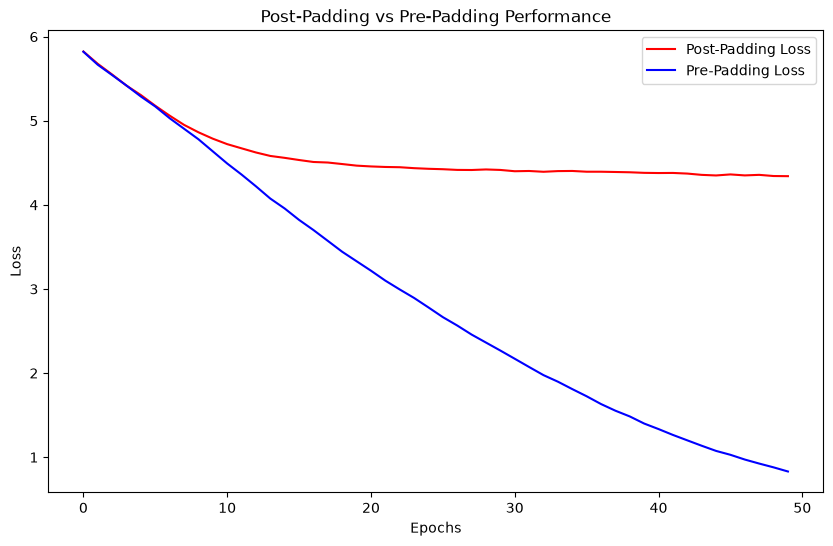

In [48]:
import matplotlib.pyplot as plt

train(mode="pre")
train(mode="post")

plt.figure(figsize=(10, 6))
plt.plot(post_losses, label="Post-Padding Loss", color='red')
plt.plot(pre_losses, label="Pre-Padding Loss", color='blue')
plt.title("Post-Padding vs Pre-Padding Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Observation → Recurrent Neural Networks (RNNs) exhibit a strong bias toward recent inputs due to their sequential processing nature, where the final hidden state is disproportionately influenced by the most recent tokens. In post-padding, the sequence ends with a block of zero-valued padding tokens. Consequently, the model processes these meaningless zeros immediately before generating the output or computing the loss, causing the hidden state to drift toward a 'zero' bias. This dilutes the contextual information from the actual data, leading to slower convergence. Conversely, pre-padding places meaningful tokens at the end of the sequence. This ensures the final hidden state retains high-fidelity contextual information, preventing the model from being biased by padding and resulting in faster loss reduction.